In [1]:
import numpy as np
from matplotlib import pyplot as plt
import os
from scipy.spatial import Voronoi, voronoi_plot_2d
import pandas as pd
import geopandas as gpd
import charset_normalizer

/home/harris/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
path = "/home/harris/Downloads/Shasee/Assignment 8/GWDBDownload/GWDBDownload"
os.chdir(path)

In [3]:
fname = 'WellMain.txt'
watqual = 'WaterQualityMajor.txt'
bndfile = 'Hardin.gpkg'
res1 = charset_normalizer.from_path(fname).best()
res2 = charset_normalizer.from_path(watqual).best()
print('WellMain.txt Encoding:', (res1.encoding), 'and', 'WaterQualityMajor.txt Encoding:', (res2.encoding))

WellMain.txt Encoding: cp1250 and WaterQualityMajor.txt Encoding: ascii


In [4]:
wells = pd.read_csv(fname, sep = '|', encoding = 'cp1250', dtype = 'str')
wells.head()

,StateWellNumber,County,RiverBasin,GMA,RWPA,GCD,AquiferCode,AquiferCodeDescription,AquiferId,Aquifer,...,WellReportTrackingNumber,PluggingReportTrackingNumber,USGSSiteNumber,TCEQSourceId,GCDWellNumber,OwnerWellNumber,OtherWellNumber,PreviousStateWellNumber,CreatedDate,LastUpdateDate
0,0140301,Dallam,Canadian,1,A - Panhandle,North Plains GCD,121OGDP,"Ogallala Formation, Dakota Group and Purgatoir...",58,Ogallala/Rita Blanca,...,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,2004-05-18,2025-05-13
1,0140302,Dallam,Canadian,1,A - Panhandle,North Plains GCD,121OGDP,"Ogallala Formation, Dakota Group and Purgatoir...",58,Ogallala/Rita Blanca,...,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,2003-12-23,2022-12-02
2,0140601,Dallam,Canadian,1,A - Panhandle,North Plains GCD,211DKOP,Dakota Group and Purgatoire Formation,23,Rita Blanca,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-12-01,2020-01-16
3,0140901,Dallam,Canadian,1,A - Panhandle,North Plains GCD,121OGLL,Ogallala Formation,21,Ogallala,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1966-08-30,2018-03-27
4,0140902,Dallam,Canadian,1,A - Panhandle,North Plains GCD,121OGLD,Ogallala Formation and Dakota Group,58,Ogallala/Rita Blanca,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-10-01,2020-01-16


In [5]:
wells.columns

Index(['StateWellNumber', 'County', 'RiverBasin', 'GMA', 'RWPA', 'GCD',
       'AquiferCode', 'AquiferCodeDescription', 'AquiferId', 'Aquifer',
       'Classification', 'AquiferPickMethod', 'LatitudeDD', 'Dlat', 'Mlat',
       'Slat', 'LongitudeDD', 'Dlong', 'Mlong', 'Slong', 'CoordinateSource',
       'Owner', 'Driller', 'WellDepth', 'DepthSource', 'LandSurfaceElevation',
       'LandSurfaceElevationMethod', 'DrillingStartDate', 'DrillingMonth',
       'DrillingDay', 'DrillingYear', 'DrillingEndDate', 'DrillingMethod',
       'BoreHoleCompletion', 'WellType', 'Pump', 'PowerType', 'WellUse',
       'WaterLevelStatus', 'CurrentWaterLevelWell', 'WaterQualityAvailable',
       'CurrentWaterQualityWell', 'ReportingAgency', 'OtherDataAvailable',
       'Remarks', 'WellReportTrackingNumber', 'PluggingReportTrackingNumber',
       'USGSSiteNumber', 'TCEQSourceId', 'GCDWellNumber', 'OwnerWellNumber',
       'OtherWellNumber', 'PreviousStateWellNumber', 'CreatedDate',
       'LastUpdateDate'],


In [6]:
watquality = pd.read_csv(watqual, sep = '|', encoding = 'ascii', dtype = 'str')
watquality.head()

,StateWellNumber,County,Aquifer,SampleMonth,SampleDay,SampleYear,SampleDate,SampleTime,SampleTimeZone,SampleNumber,...,SampleBU,SampleBUValue,ParameterCode,ParameterDescription,ParameterUnitOfMeasure,ParameterFlag,ParameterValue,ParameterValuePlusMinus,CreatedDate,LastUpdateDate
0,0148904,Dallam,Ogallala,9,18,1992,1992-09-18,1430,NaN,1,...,B,NaN,39086,ALKALINITY FIELD DISSOLVED AS CACO3,MG/L AS CACO3,NaN,186,NaN,NaN,NaN
1,0148904,Dallam,Ogallala,9,18,1992,1992-09-18,1430,NaN,1,...,B,NaN,00415,"ALKALINITY, PHENOLPHTHALEIN (MG/L)",mg/L,NaN,0,NaN,2016-04-28,NaN
2,0148904,Dallam,Ogallala,9,18,1992,1992-09-18,1430,NaN,1,...,B,NaN,00410,"ALKALINITY, TOTAL (MG/L AS CACO3)",MG/L AS CACO3,NaN,188,NaN,2016-04-28,NaN
3,0148904,Dallam,Ogallala,9,18,1992,1992-09-18,1430,NaN,1,...,B,NaN,01503,"ALPHA, DISSOLVED (PC/L)",PC/L,NaN,6.4000000000000004,2.6000000000000001,NaN,NaN
4,0148904,Dallam,Ogallala,9,18,1992,1992-09-18,1430,NaN,1,...,B,NaN,01000,"ARSENIC, DISSOLVED (UG/L AS AS)",ug/L,<,10,NaN,NaN,NaN


In [7]:
watquality.columns

Index(['StateWellNumber', 'County', 'Aquifer', 'SampleMonth', 'SampleDay',
       'SampleYear', 'SampleDate', 'SampleTime', 'SampleTimeZone',
       'SampleNumber', 'Reliability', 'CollectionEntity', 'AnalyzedLab',
       'SampledAquifer', 'SampleTopInterval', 'SampleBottomInterval',
       'CollectionRemarks', 'SampleBU', 'SampleBUValue', 'ParameterCode',
       'ParameterDescription', 'ParameterUnitOfMeasure', 'ParameterFlag',
       'ParameterValue', 'ParameterValuePlusMinus', 'CreatedDate',
       'LastUpdateDate'],
      dtype='object')

In [8]:
watqualitya = watquality[['StateWellNumber','County', 'Aquifer','ParameterCode', 'ParameterValue', 'ParameterUnitOfMeasure']]
watqualitya

,StateWellNumber,County,Aquifer,ParameterCode,ParameterValue,ParameterUnitOfMeasure
0,0148904,Dallam,Ogallala,39086,186,MG/L AS CACO3
1,0148904,Dallam,Ogallala,00415,0,mg/L
2,0148904,Dallam,Ogallala,00410,188,MG/L AS CACO3
3,0148904,Dallam,Ogallala,01503,6.4000000000000004,PC/L
4,0148904,Dallam,Ogallala,01000,10,ug/L
...,...,...,...,...,...,...
2227137,8905404,Cameron,Gulf Coast,00932,81,PCT
2227138,8905404,Cameron,Gulf Coast,00929,1280,mg/L
2227139,8905404,Cameron,Gulf Coast,00094,8160,MICR
2227140,8905404,Cameron,Gulf Coast,00945,1929,MG/L AS SO4


In [9]:
ECHar = watqualitya.loc[(watqualitya['County'] == 'Hardin') & (watqualitya['ParameterCode'] == '00094'), ['StateWellNumber','ParameterCode', 'ParameterValue']]
ECHar.head()

,StateWellNumber,ParameterCode,ParameterValue
1465477,6129803,00094,410
1465517,6129803,00094,360
1465562,6129803,00094,355
1465609,6129803,00094,332
1465654,6129803,00094,311


In [10]:
wellsHard = wells.loc[(wells['County'] == 'Hardin'), ['StateWellNumber','LatitudeDD', 'LongitudeDD']]
wellsHard.head()

,StateWellNumber,LatitudeDD,LongitudeDD
104111,6129701,30.5172220,-94.4683330
104112,6129702,30.5147230,-94.4619450
104118,6129801,30.5061120,-94.4541670
104119,6129802,30.5036120,-94.4236110
104120,6129803,30.5119450,-94.4477780


In [11]:
EChard2 = ECHar.merge(wellsHard, on ='StateWellNumber', how = 'inner')
EChard2

,StateWellNumber,ParameterCode,ParameterValue,LatitudeDD,LongitudeDD
0,6129803,00094,410,30.5119450,-94.4477780
1,6129803,00094,360,30.5119450,-94.4477780
2,6129803,00094,355,30.5119450,-94.4477780
3,6129803,00094,332,30.5119450,-94.4477780
4,6129803,00094,311,30.5119450,-94.4477780
...,...,...,...,...,...
258,6161309,00094,897,30.1230550,-94.4088890
259,6161309,00094,883,30.1230550,-94.4088890
260,6161309,00094,662,30.1230550,-94.4088890
261,6161309,00094,1065,30.1230550,-94.4088890


In [12]:
ECHard2 = EChard2.rename(columns={'ParameterValue': 'EC'})
ECHard2.head()

,StateWellNumber,ParameterCode,EC,LatitudeDD,LongitudeDD
0,6129803,00094,410,30.5119450,-94.4477780
1,6129803,00094,360,30.5119450,-94.4477780
2,6129803,00094,355,30.5119450,-94.4477780
3,6129803,00094,332,30.5119450,-94.4477780
4,6129803,00094,311,30.5119450,-94.4477780


In [13]:
ECHard3 = ECHard2.apply(pd.to_numeric, errors = 'coerce')
ECHard3avg = ECHard3.groupby('StateWellNumber').mean().reset_index()
ECHard3avg.head()

,StateWellNumber,ParameterCode,EC,LatitudeDD,LongitudeDD
0,6129803,94.0,353.6,30.511945,-94.447778
1,6131901,94.0,104.0,30.504723,-94.164167
2,6135205,94.0,324.0,30.462501,-94.706389
3,6135501,94.0,384.0,30.437500,-94.673611
4,6135502,94.0,265.5,30.437222,-94.672500


In [14]:
ECWGS = gpd.GeoDataFrame(ECHard3avg, geometry = gpd.points_from_xy(ECHard3avg['LongitudeDD'],ECHard3avg['LatitudeDD']), crs = 'EPSG:4326')
ECAEA = ECWGS.to_crs('EPSG:5070')len(

In [20]:
len(ECAEA)

161

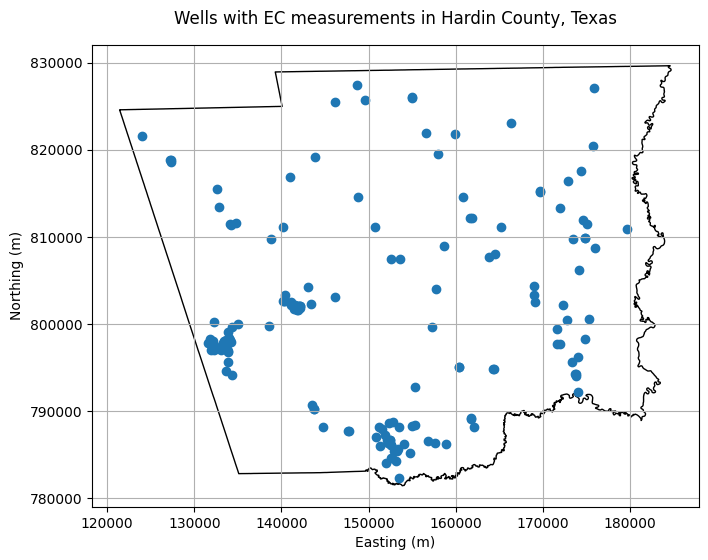

In [15]:
fig,ax =plt.subplots(figsize = (8,6))
Hardin = gpd.read_file(bndfile)
HardAEA = Hardin.to_crs('EPSG:5070')
HardAEA.plot(ax=ax, facecolor ='none', edgecolor = 'black')
ECAEA.plot(ax = ax)
plt.grid()
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')
plt.title('Wells with EC measurements in Hardin County, Texas', pad = 15)
plt.show()

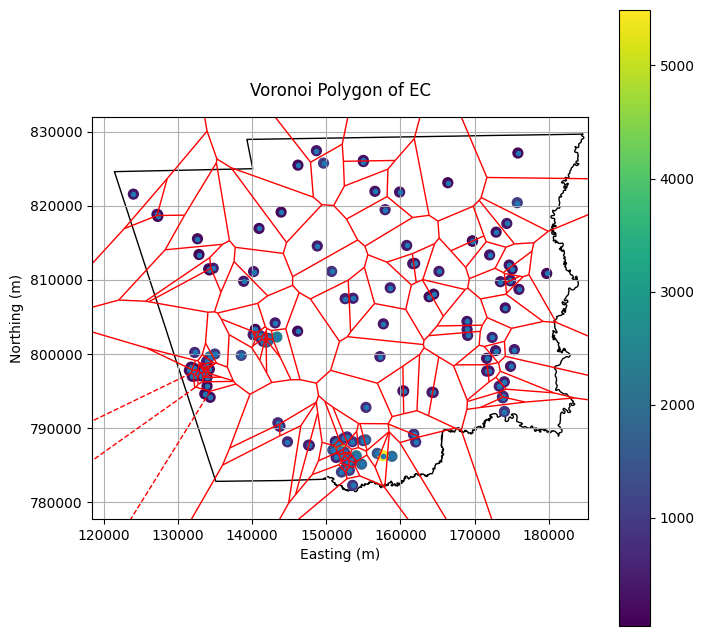

In [19]:
seedpts = np.column_stack((ECAEA.geometry.x,ECAEA.geometry.y))
vor = Voronoi(seedpts)

fig,ax =plt.subplots(figsize = (8,8))
HardAEA.plot(ax=ax, facecolor ='none', edgecolor = 'black')
voronoi_plot_2d(vor, ax=ax, show_vertices = False, line_colors = 'red')
points_plot = ECAEA.plot(ax =ax, column = 'EC', cmap ='viridis', legend =True, markersize =50)
plt.grid()
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')
plt.title('Voronoi Polygon of EC', pad = 15)
plt.show()

In [18]:
import scipy
print(scipy.__version__)

1.15.3


In [21]:
HardAEA.to_file("HardAEA.gpkg", driver="GPKG")

In [22]:
ECAEA.to_file("ECAEA.gpkg", driver="GPKG")

In [23]:
HardAEA.to_file("AEA_output.gpkg", layer="HardAEA", driver="GPKG")
ECAEA.to_file("AEA_output.gpkg", layer="ECAEA", driver="GPKG")